# 🎙️ Hebrew ASR — Full Dataset Run
**Models:** Whisper · Invrit · Caspi · Qwen3-ASR  
Run cells top to bottom. Each model saves a checkpoint every 50 clips so Colab disconnects won't lose progress.

## CELL 1 — Install & mount

In [ ]:
!pip install -q -U datasets[audio] transformers accelerate sentencepiece jiwer soundfile
!pip install -q git+https://github.com/QwenLM/Qwen3-ASR.git
!pip install -q ijson
from google.colab import drive
drive.mount('/content/drive')
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 25.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.8/416.8 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

## CELL 2 — Load ALL samples (no time limit)

In [ ]:
import os, glob, torch, numpy as np, soundfile as sf
from datasets import Dataset, concatenate_datasets, Audio

DATASET_DIR = '/content/drive/MyDrive/hebrewasr/dataset'
SAMPLE_RATE = 16_000
SAVE_DIR    = '/content/drive/MyDrive/hebrewasr/results_json'
os.makedirs(SAVE_DIR, exist_ok=True)

def _ds_to_samples(ds):
    print('Columns:', ds.column_names, '| Rows:', len(ds))
    audio_col = next((c for c in ds.column_names
                      if c in ('audio','path','file','filename','audio_path')), None)
    ds = ds.cast_column(audio_col, Audio(sampling_rate=SAMPLE_RATE))
    text_col = next((c for c in ('text','sentence','transcription',
                                  'normalized_text','transcript') if c in ds.column_names), None)
    print('Audio col:', audio_col, '| Text col:', text_col)
    samples, total = [], 0.0
    for row in ds:                          # NO break — load everything
        arr = row[audio_col]['array']
        dur = len(arr) / SAMPLE_RATE
        samples.append({'audio': arr, 'sampling_rate': SAMPLE_RATE,
                        'reference': row.get(text_col,'') if text_col else '',
                        'duration_s': dur})
        total += dur
    print(f'✅ {len(samples)} samples | {total/3600:.2f} h')
    return samples

arrows = sorted(glob.glob(os.path.join(DATASET_DIR, '**/*.arrow'), recursive=True))
print(f'Found {len(arrows)} arrow shards')
samples = _ds_to_samples(concatenate_datasets([Dataset.from_file(f) for f in arrows]))
TOTAL_AUDIO_S = sum(s['duration_s'] for s in samples)
print(f'\nReady: {len(samples)} samples | {TOTAL_AUDIO_S/3600:.2f} h total')

Found 3 arrow shards
Columns: ['fname', 'audio', 'n_samples', 'text', 'normalized_text', 'score', 'raw', 'is_raw', 'source'] | Rows: 9360
Audio col: audio | Text col: text
✅ 9360 samples | 7.52 h

Ready: 9360 samples | 7.52 h total


In [ ]:
TARGET_SECONDS = 30 * 60   # 30 minutes

In [ ]:
target_seconds = 30 * 60

samples_30min = []
total = 0.0

for s in samples:
    if total + s["duration_s"] > target_seconds:
        break
    samples_30min.append(s)
    total += s["duration_s"]

samples = samples_30min

print(f"Ready: {len(samples)} samples | {total/60:.2f} min total")

Ready: 610 samples | 29.97 min total


## CELL 3 — Whisper large-v3 (all samples)

In [ ]:
import gc, json, time, torch
from transformers import pipeline, AutoModelForSpeechSeq2Seq, AutoProcessor

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16 if torch.cuda.is_available() else torch.float32
CKPT   = os.path.join(SAVE_DIR, 'whisper_checkpoint.json')

print('Loading Whisper large-v3 ...')
whisper_model = AutoModelForSpeechSeq2Seq.from_pretrained(
    'openai/whisper-large-v3',
    torch_dtype=DTYPE, low_cpu_mem_usage=True, use_safetensors=True
).to(DEVICE)
whisper_proc = AutoProcessor.from_pretrained('openai/whisper-large-v3')
whisper_pipe = pipeline(
    'automatic-speech-recognition',
    model=whisper_model, tokenizer=whisper_proc.tokenizer,
    feature_extractor=whisper_proc.feature_extractor,
    torch_dtype=DTYPE, device=DEVICE,
    generate_kwargs={'language': 'he', 'task': 'transcribe'},
    chunk_length_s=30, stride_length_s=5,
)
print('✅ Whisper loaded\n')

# Resume from checkpoint
if os.path.exists(CKPT):
    with open(CKPT, encoding='utf-8') as f: whisper_results = json.load(f)
    start_i = len(whisper_results)
    print(f'Resuming from clip {start_i}')
else:
    whisper_results, start_i = [], 0

t_start = time.perf_counter()
for i, s in enumerate(samples):
    if i < start_i: continue
    t0  = time.perf_counter()
    out = whisper_pipe({'array': s['audio'], 'sampling_rate': s['sampling_rate']})
    rtf = (time.perf_counter() - t0) / s['duration_s']
    whisper_results.append({'text': out['text'], 'rtf': rtf,
                            'reference': s['reference'], 'duration_s': s['duration_s']})
    if (i + 1) % 10 == 0 or i < 3:
        print(f'[{i+1}/{len(samples)}] RTF={rtf:.2f}x | {s["duration_s"]:.1f}s')
        print(f'  REF: {s["reference"][:80]}')
        print(f'  HYP: {out["text"][:80]}')
    if (i + 1) % 50 == 0:
        with open(CKPT, 'w', encoding='utf-8') as f: json.dump(whisper_results, f, ensure_ascii=False, indent=2)
        print(f'  💾 Checkpoint saved at clip {i+1}')

with open(CKPT, 'w', encoding='utf-8') as f: json.dump(whisper_results, f, ensure_ascii=False, indent=2)
wall = time.perf_counter() - t_start
print(f'\n✅ Whisper done — {len(whisper_results)} clips | {wall/60:.1f} min')
del whisper_pipe, whisper_model, whisper_proc
gc.collect(); torch.cuda.empty_cache()

Loading Whisper large-v3 ...


`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


✅ Whisper loaded

[1/610] RTF=1.28x | 2.4s
  REF: יואו
  HYP:  יואו!
[2/610] RTF=0.63x | 1.1s
  REF: זה כן
  HYP:  איזה, כאלה.
[3/610] RTF=0.66x | 1.8s
  REF: כן זה דווקא יתחיל מבטיח
  HYP:  כן, זה דווקא התחיל לפתיח,


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[10/610] RTF=0.66x | 1.4s
  REF: פה באולפני רנצי
  HYP:  פובול, פני רנצי.
[20/610] RTF=0.37x | 2.3s
  REF: אה ינג סטונר לייף כל
  HYP:  ה-Youngstoner Life, כל...
[30/610] RTF=0.56x | 3.8s
  REF: אז עדני רק עכשיו כי באמת הכרתי אותם אישית ואני עדיין מאוד מאוד גאה בהם
  HYP:  אז רק עכשיו כי באמת הכרתי אותם מוזית ואני עדיין מאוד מאוד גאה בהם.
[40/610] RTF=0.40x | 2.0s
  REF: שזה בעצם המישור שהוא
  HYP:  שזה בעצם המישור שהוא
[50/610] RTF=0.62x | 1.9s
  REF: מדהים בשביל התרבות מה שהם עושים
  HYP:  מדהים בשביל התרבות מה שהם עושים
  💾 Checkpoint saved at clip 50
[60/610] RTF=0.55x | 3.6s
  REF: זה ההופעה שסבלים מן הגמה ועשה את הפינלי נכון
  HYP:  זה הופעה שסבלים מנגמה ועשה את הפינלי, נכון?
[70/610] RTF=0.44x | 4.7s
  REF: את רון נשר שהוא בכלל זרם שלישי והם עצמם שהם גם
  HYP:  את רון נשר שהוא בכלל זרם שלישי והם עצמם שהם גם
[80/610] RTF=0.49x | 2.5s
  REF: אחד השירים הכי טובים שלהם בכלל
  HYP:  אחד השירים הכי טובים שלהם ובכלל
[90/610] RTF=0.34x | 1.8s
  REF: תשפע
  HYP:  תשפה.
[100/610] RTF=0.46

## CELL 4 — Invrit (all samples)

In [ ]:
import gc, json, time, torch
from transformers import pipeline, AutoModelForSpeechSeq2Seq, AutoProcessor

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16 if torch.cuda.is_available() else torch.float32
CKPT   = os.path.join(SAVE_DIR, 'invrit_checkpoint.json')

print('Loading Invrit (ivrit-ai/whisper-large-v3-turbo) ...')
inv_model = AutoModelForSpeechSeq2Seq.from_pretrained(
    'ivrit-ai/whisper-large-v3-turbo',
    torch_dtype=DTYPE, low_cpu_mem_usage=True, use_safetensors=True
).to(DEVICE)
inv_proc = AutoProcessor.from_pretrained('ivrit-ai/whisper-large-v3-turbo')
inv_pipe = pipeline(
    'automatic-speech-recognition',
    model=inv_model, tokenizer=inv_proc.tokenizer,
    feature_extractor=inv_proc.feature_extractor,
    torch_dtype=DTYPE, device=DEVICE,
    generate_kwargs={'language': 'he', 'task': 'transcribe'},
    chunk_length_s=30, stride_length_s=5,
)
print('✅ Invrit loaded\n')

if os.path.exists(CKPT):
    with open(CKPT, encoding='utf-8') as f: invrit_results = json.load(f)
    start_i = len(invrit_results)
    print(f'Resuming from clip {start_i}')
else:
    invrit_results, start_i = [], 0

t_start = time.perf_counter()
for i, s in enumerate(samples):
    if i < start_i: continue
    t0  = time.perf_counter()
    out = inv_pipe({'array': s['audio'], 'sampling_rate': s['sampling_rate']})
    rtf = (time.perf_counter() - t0) / s['duration_s']
    invrit_results.append({'text': out['text'], 'rtf': rtf,
                           'reference': s['reference'], 'duration_s': s['duration_s']})
    if (i + 1) % 10 == 0 or i < 3:
        print(f'[{i+1}/{len(samples)}] RTF={rtf:.2f}x | {s["duration_s"]:.1f}s')
        print(f'  REF: {s["reference"][:80]}')
        print(f'  HYP: {out["text"][:80]}')
    if (i + 1) % 50 == 0:
        with open(CKPT, 'w', encoding='utf-8') as f: json.dump(invrit_results, f, ensure_ascii=False, indent=2)
        print(f'  💾 Checkpoint saved at clip {i+1}')

with open(CKPT, 'w', encoding='utf-8') as f: json.dump(invrit_results, f, ensure_ascii=False, indent=2)
wall = time.perf_counter() - t_start
print(f'\n✅ Invrit done — {len(invrit_results)} clips | {wall/60:.1f} min')
del inv_pipe, inv_model, inv_proc
gc.collect(); torch.cuda.empty_cache()

Loading Invrit (ivrit-ai/whisper-large-v3-turbo) ...


Device set to use cuda
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


✅ Invrit loaded



`generation_config` default values have been modified to match model-specific defaults: {'suppress_tokens': [], 'begin_suppress_tokens': [220, 50257]}. If this is not desired, please set these values explicitly.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProce

[1/610] RTF=0.61x | 2.4s
  REF: יואו
  HYP:  יואוווווווווווווווווווווווווווווווווווווווווווו
[2/610] RTF=0.26x | 1.1s
  REF: זה כן
  HYP:  איזה... כן, אה...
[3/610] RTF=0.19x | 1.8s
  REF: כן זה דווקא יתחיל מבטיח
  HYP:  כן, זה דווקא יתחיל מבטיח.
[10/610] RTF=0.24x | 1.4s
  REF: פה באולפני רנצי
  HYP:  פה באולפני ראנצי
[20/610] RTF=0.19x | 2.3s
  REF: אה ינג סטונר לייף כל
  HYP:  אה, יאנג סטונר לייף, כל ה...
[30/610] RTF=0.14x | 3.8s
  REF: אז עדני רק עכשיו כי באמת הכרתי אותם אישית ואני עדיין מאוד מאוד גאה בהם
  HYP:  אז אני רק עכשיו, כי באמת הכרתי אותם אישית, ואני עדיין מאוד מאוד גאה בהם.
[40/610] RTF=0.37x | 2.0s
  REF: שזה בעצם המישור שהוא
  HYP:  שזה בעצם המישור שהוא...
[50/610] RTF=0.18x | 1.9s
  REF: מדהים בשביל התרבות מה שהם עושים
  HYP:  מדהים בשביל התרבות מה שהם עושים.
  💾 Checkpoint saved at clip 50
[60/610] RTF=0.12x | 3.6s
  REF: זה ההופעה שסבלים מן הגמה ועשה את הפינלי נכון
  HYP:  זה ההופעה שסבלים מן הגמה ועשה את הפינאלי, נכון?
[70/610] RTF=0.09x | 4.7s
  REF: את רון נשר ש

## CELL 5 — Caspi (all samples)

In [ ]:
import gc, json, time, torch
from qwen_asr import Qwen3ASRModel

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

CKPT = os.path.join(SAVE_DIR, 'caspi_checkpoint.json')

print('Loading Caspi (OzLabs/Caspi-1.7B) ...')
caspi_model = Qwen3ASRModel.from_pretrained(
    'OzLabs/Caspi-1.7B',
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map='cuda:0' if torch.cuda.is_available() else 'cpu',
    max_inference_batch_size=1,
    max_new_tokens=256,
)
print('✅ Caspi loaded\n')

if os.path.exists(CKPT):
    with open(CKPT, encoding='utf-8') as f: caspi_results = json.load(f)
    start_i = len(caspi_results)
    print(f'Resuming from clip {start_i}')
else:
    caspi_results, start_i = [], 0

t_start = time.perf_counter()
for i, s in enumerate(samples):
    if i < start_i: continue
    t0     = time.perf_counter()
    result = caspi_model.transcribe(audio=(s['audio'], s['sampling_rate']), language=None)
    rtf    = (time.perf_counter() - t0) / s['duration_s']
    hyp    = result[0].text.strip()
    caspi_results.append({'text': hyp, 'rtf': rtf,
                          'reference': s['reference'], 'duration_s': s['duration_s']})
    del result
    gc.collect(); torch.cuda.empty_cache()
    if (i + 1) % 10 == 0 or i < 3:
        print(f'[{i+1}/{len(samples)}] RTF={rtf:.2f}x | {s["duration_s"]:.1f}s')
        print(f'  REF: {s["reference"][:80]}')
        print(f'  HYP: {hyp[:80]}')
    if (i + 1) % 50 == 0:
        with open(CKPT, 'w', encoding='utf-8') as f: json.dump(caspi_results, f, ensure_ascii=False, indent=2)
        print(f'  💾 Checkpoint saved at clip {i+1}')

with open(CKPT, 'w', encoding='utf-8') as f: json.dump(caspi_results, f, ensure_ascii=False, indent=2)
wall = time.perf_counter() - t_start
print(f'\n✅ Caspi done — {len(caspi_results)} clips | {wall/60:.1f} min')
del caspi_model
gc.collect(); torch.cuda.empty_cache()

Loading Caspi (OzLabs/Caspi-1.7B) ...


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


✅ Caspi loaded



Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[1/610] RTF=0.48x | 2.4s
  REF: יואו
  HYP: איוב!


...

[590/610] RTF=0.29x | 3.4s
  REF: אני לא זוכר אם הוא לא זה ג'נה אופסה
  HYP: אני לא זוכר אם הוא. לא, זה ג'נר עושה.


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[600/610] RTF=0.66x | 1.1s
  REF: קרה מהר באנגלית קדימה
  HYP: קראה מהר באנגלית, קדימה
  💾 Checkpoint saved at clip 600


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[610/610] RTF=0.31x | 1.4s
  REF: כל הזמן שינויים בזה
  HYP: כל הזמן שינויים בזה

✅ Caspi done — 610 clips | 15.6 min


## CELL 6 — Qwen3-ASR (all samples)

In [ ]:
import gc, json, time, torch
from qwen_asr import Qwen3ASRModel

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

CKPT = os.path.join(SAVE_DIR, 'qwen_checkpoint.json')

print('Loading Qwen3-ASR (Qwen/Qwen3-ASR-1.7B) ...')
qwen_model = Qwen3ASRModel.from_pretrained(
    'Qwen/Qwen3-ASR-1.7B',
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map='cuda:0' if torch.cuda.is_available() else 'cpu',
    max_inference_batch_size=1,
    max_new_tokens=256,
)
print('✅ Qwen3-ASR loaded\n')

if os.path.exists(CKPT):
    with open(CKPT, encoding='utf-8') as f: qwen_results = json.load(f)
    start_i = len(qwen_results)
    print(f'Resuming from clip {start_i}')
else:
    qwen_results, start_i = [], 0

t_start = time.perf_counter()
for i, s in enumerate(samples):
    if i < start_i: continue
    t0     = time.perf_counter()
    result = qwen_model.transcribe(audio=(s['audio'], s['sampling_rate']), language=None)
    rtf    = (time.perf_counter() - t0) / s['duration_s']
    hyp    = result[0].text.strip()
    qwen_results.append({'text': hyp, 'rtf': rtf,
                         'reference': s['reference'], 'duration_s': s['duration_s']})
    del result
    gc.collect(); torch.cuda.empty_cache()
    if (i + 1) % 10 == 0 or i < 3:
        print(f'[{i+1}/{len(samples)}] RTF={rtf:.2f}x | {s["duration_s"]:.1f}s')
        print(f'  REF: {s["reference"][:80]}')
        print(f'  HYP: {hyp[:80]}')
    if (i + 1) % 50 == 0:
        with open(CKPT, 'w', encoding='utf-8') as f: json.dump(qwen_results, f, ensure_ascii=False, indent=2)
        print(f'  💾 Checkpoint saved at clip {i+1}')

with open(CKPT, 'w', encoding='utf-8') as f: json.dump(qwen_results, f, ensure_ascii=False, indent=2)
wall = time.perf_counter() - t_start
print(f'\n✅ Qwen done — {len(qwen_results)} clips | {wall/60:.1f} min')
del qwen_model
gc.collect(); torch.cuda.empty_cache()

Loading Qwen3-ASR (Qwen/Qwen3-ASR-1.7B) ...


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


✅ Qwen3-ASR loaded



Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


...

[590/610] RTF=0.40x | 3.4s
  REF: אני לא זוכר אם הוא לא זה ג'נה אופסה
  HYP: הל הלוס זוכרים וו וו לא זה זה ג'אנו פסח.


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[600/610] RTF=0.56x | 1.1s
  REF: קרה מהר באנגלית קדימה
  HYP: קרא Mayer באנגלית קדימה.
  💾 Checkpoint saved at clip 600


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[610/610] RTF=0.43x | 1.4s
  REF: כל הזמן שינויים בזה
  HYP: כל הזמן שינוים בזה.

✅ Qwen done — 610 clips | 17.2 min


## CELL 7 — WER / CER comparison + chart


  Model           Clips   WER %   CER %   Avg RTF
──────────────────────────────────────────────────────────
  Whisper           610  25.11%   14.45%     0.562x
  Invrit            610  22.93%   14.15%     0.185x
  Caspi             610  25.02%   12.21%     0.419x
  Qwen3-ASR         610  71.99%   39.30%     0.463x


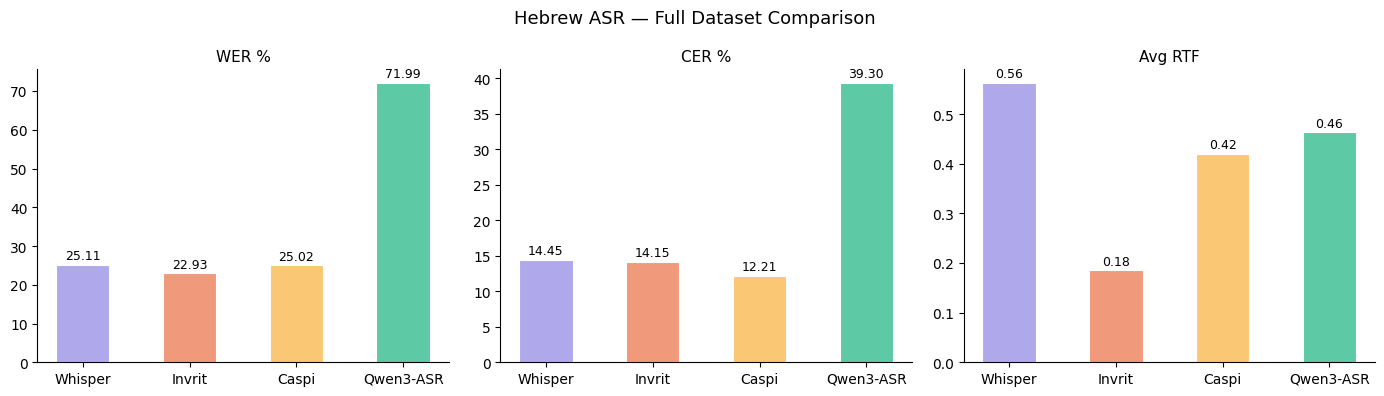

Chart saved → /content/drive/MyDrive/hebrewasr/results_json/comparison_chart.png
Summary saved → /content/drive/MyDrive/hebrewasr/results_json/final_summary.json


In [ ]:
import re, json, unicodedata, matplotlib.pyplot as plt
from jiwer import wer, cer

def normalize_hebrew(text):
    if not isinstance(text, str): return ''
    text = unicodedata.normalize('NFKC', text)
    text = re.sub(r'[\u0591-\u05C7]', '', text)   # strip nikud
    text = text.replace('ך','כ').replace('ם','מ').replace('ן','נ').replace('ף','פ').replace('ץ','צ')
    text = re.sub(r'[^0-9A-Za-z\u05D0-\u05EA\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def score(results, name):
    scored = [r for r in results if r.get('reference','').strip()]
    if not scored:
        print(f'{name}: no references — skipping WER/CER')
        return None
    refs = [normalize_hebrew(r['reference']) for r in scored]
    hyps = [normalize_hebrew(r['text'])      for r in scored]
    return {
        'model': name,
        'clips': len(scored),
        'wer':   round(wer(refs, hyps) * 100, 2),
        'cer':   round(cer(refs, hyps) * 100, 2),
        'rtf':   round(sum(r['rtf'] for r in results) / len(results), 3),
    }

all_scores = []
for name, res in [
    ('Whisper',   globals().get('whisper_results')),
    ('Invrit',    globals().get('invrit_results')),
    ('Caspi',     globals().get('caspi_results')),
    ('Qwen3-ASR', globals().get('qwen_results')),
]:
    if res:
        s = score(res, name)
        if s: all_scores.append(s)
    else:
        # try loading from checkpoint file
        ckpt = os.path.join(SAVE_DIR, f'{name.lower().replace("-","_").replace("3_asr","")}_checkpoint.json')
        if os.path.exists(ckpt):
            with open(ckpt, encoding='utf-8') as f: res = json.load(f)
            s = score(res, name)
            if s: all_scores.append(s)
        else:
            print(f'Skipping {name} — no results')

# ── table ────────────────────────────────────────────────────
print(f'\n{"="*58}')
print(f'  {"Model":<14} {"Clips":>6} {"WER %":>7} {"CER %":>7} {"Avg RTF":>9}')
print(f'{"─"*58}')
for s in all_scores:
    print(f"  {s['model']:<14} {s['clips']:>6} {s['wer']:>6.2f}%  {s['cer']:>6.2f}%  {s['rtf']:>8.3f}x")
print(f'{"="*58}')

# ── chart ────────────────────────────────────────────────────
names  = [s['model'] for s in all_scores]
colors = ['#AFA9EC','#F0997B','#FAC775','#5DCAA5'][:len(all_scores)]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, vals, title in zip(
    axes,
    [[s['wer'] for s in all_scores], [s['cer'] for s in all_scores], [s['rtf'] for s in all_scores]],
    ['WER %', 'CER %', 'Avg RTF'],
):
    bars = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=0.8, width=0.5)
    ax.set_title(title, fontsize=11)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)
fig.suptitle('Hebrew ASR — Full Dataset Comparison', fontsize=13, fontweight='500')
plt.tight_layout()
chart = os.path.join(SAVE_DIR, 'comparison_chart.png')
plt.savefig(chart, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved →', chart)

# ── save summary ─────────────────────────────────────────────
summary = os.path.join(SAVE_DIR, 'final_summary.json')
with open(summary, 'w', encoding='utf-8') as f:
    json.dump(all_scores, f, ensure_ascii=False, indent=2)
print('Summary saved →', summary)

## 2nd iteration

In [ ]:
!pip install -q -U datasets[audio] transformers accelerate sentencepiece jiwer soundfile
!pip install -q git+https://github.com/QwenLM/Qwen3-ASR.git
!pip install -q ijson
from google.colab import drive
drive.mount('/content/drive')
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 22.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.8/416.8 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 120.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

# CELL 2 — Load samples (always needed after restart):

In [ ]:
import os, glob, torch, numpy as np
from datasets import Dataset, concatenate_datasets, Audio

DATASET_DIR = '/content/drive/MyDrive/hebrewasr/dataset'
SAVE_DIR    = '/content/drive/MyDrive/hebrewasr/results_json'
SAMPLE_RATE = 16_000

def _ds_to_samples(ds):
    audio_col = next((c for c in ds.column_names if c in ('audio','path','file','filename','audio_path')), None)
    ds = ds.cast_column(audio_col, Audio(sampling_rate=SAMPLE_RATE))
    text_col = next((c for c in ('text','sentence','transcription','normalized_text','transcript') if c in ds.column_names), None)
    samples, total = [], 0.0
    for row in ds:
        arr = row[audio_col]['array']
        dur = len(arr) / SAMPLE_RATE
        samples.append({'audio': arr, 'sampling_rate': SAMPLE_RATE,
                        'reference': row.get(text_col,'') if text_col else '',
                        'duration_s': dur})
        total += dur
    print(f'✅ {len(samples)} samples | {total/3600:.2f} h')
    return samples

arrows = sorted(glob.glob(os.path.join(DATASET_DIR, '**/*.arrow'), recursive=True))
samples = _ds_to_samples(concatenate_datasets([Dataset.from_file(f) for f in arrows]))
TOTAL_AUDIO_S = sum(s['duration_s'] for s in samples)
print(f'Ready: {len(samples)} samples | {TOTAL_AUDIO_S/3600:.2f} h')

✅ 9360 samples | 7.52 h
Ready: 9360 samples | 7.52 h


# CELL 3 — Load existing results from Drive (no re-transcription needed):

In [ ]:
import json

def load_ckpt(name):
    path = os.path.join(SAVE_DIR, f'{name}_checkpoint.json')
    if os.path.exists(path):
        with open(path, encoding='utf-8') as f: data = json.load(f)
        print(f'✅ {name}: {len(data)} clips loaded from checkpoint')
        return data
    print(f'❌ {name}: no checkpoint found at {path}')
    return None

whisper_results = load_ckpt('whisper')
invrit_results  = load_ckpt('invrit')
caspi_results   = load_ckpt('caspi')
qwen_results    = load_ckpt('qwen')

✅ whisper: 610 clips loaded from checkpoint
✅ invrit: 610 clips loaded from checkpoint
✅ caspi: 610 clips loaded from checkpoint
✅ qwen: 610 clips loaded from checkpoint


# *CELL A — Qwen fix (add language='he'):*

In [ ]:
# Qwen3-ASR re-run with Hebrew language forced
import gc, json, time, torch, os
from qwen_asr import Qwen3ASRModel

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

CKPT = os.path.join(SAVE_DIR, 'qwen_he_checkpoint.json')

print('Loading Qwen3-ASR ...')
qwen_model = Qwen3ASRModel.from_pretrained(
    'Qwen/Qwen3-ASR-1.7B',
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map='cuda:0' if torch.cuda.is_available() else 'cpu',
    max_inference_batch_size=1,
    max_new_tokens=256,
)
print('✅ Qwen loaded\n')

if os.path.exists(CKPT):
    with open(CKPT, encoding='utf-8') as f: qwen_he_results = json.load(f)
    start_i = len(qwen_he_results)
    print(f'Resuming from clip {start_i}')
else:
    qwen_he_results, start_i = [], 0

t_start = time.perf_counter()
for i, s in enumerate(samples):
    if i < start_i: continue
    t0     = time.perf_counter()
    result = qwen_model.transcribe(
        audio=(s['audio'], s['sampling_rate']),
        language='he'          # ← THE FIX
    )
    rtf = (time.perf_counter() - t0) / s['duration_s']
    hyp = result[0].text.strip()
    qwen_he_results.append({'text': hyp, 'rtf': rtf,
                            'reference': s['reference'], 'duration_s': s['duration_s']})
    del result
    gc.collect(); torch.cuda.empty_cache()
    if (i + 1) % 10 == 0 or i < 3:
        print(f'[{i+1}/{len(samples)}] RTF={rtf:.2f}x')
        print(f'  REF: {s["reference"][:80]}')
        print(f'  HYP: {hyp[:80]}')
    if (i + 1) % 50 == 0:
        with open(CKPT, 'w', encoding='utf-8') as f: json.dump(qwen_he_results, f, ensure_ascii=False, indent=2)
        print(f'  💾 Checkpoint at clip {i+1}')

with open(CKPT, 'w', encoding='utf-8') as f: json.dump(qwen_he_results, f, ensure_ascii=False, indent=2)
wall = time.perf_counter() - t_start
print(f'\n✅ Qwen+he done — {len(qwen_he_results)} clips | {wall/60:.1f} min')
del qwen_model
gc.collect(); torch.cuda.empty_cache()

Loading Qwen3-ASR ...


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✅ Qwen loaded



ValueError: Unsupported language: He. Supported: ['Chinese', 'English', 'Cantonese', 'Arabic', 'German', 'French', 'Spanish', 'Portuguese', 'Indonesian', 'Italian', 'Korean', 'Russian', 'Thai', 'Vietnamese', 'Japanese', 'Turkish', 'Hindi', 'Malay', 'Dutch', 'Swedish', 'Danish', 'Finnish', 'Polish', 'Czech', 'Filipino', 'Persian', 'Greek', 'Romanian', 'Hungarian', 'Macedonian']



# *CELL B — Invrit with beam search + longer context:*



In [ ]:
# Invrit improved — beam search + 60s chunks
import gc, json, time, torch, os
from transformers import pipeline, AutoModelForSpeechSeq2Seq, AutoProcessor

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16 if torch.cuda.is_available() else torch.float32
CKPT   = os.path.join(SAVE_DIR, 'invrit_beam_checkpoint.json')

print('Loading Invrit improved ...')
inv_model = AutoModelForSpeechSeq2Seq.from_pretrained(
    'ivrit-ai/whisper-large-v3-turbo',
    torch_dtype=DTYPE, low_cpu_mem_usage=True, use_safetensors=True
).to(DEVICE)
inv_proc = AutoProcessor.from_pretrained('ivrit-ai/whisper-large-v3-turbo')
inv_pipe = pipeline(
    'automatic-speech-recognition',
    model=inv_model, tokenizer=inv_proc.tokenizer,
    feature_extractor=inv_proc.feature_extractor,
    torch_dtype=DTYPE, device=DEVICE,
    generate_kwargs={
        'language': 'he',
        'task': 'transcribe',
        'num_beams': 5,          # ← beam search (was greedy)
    },
    chunk_length_s=60,           # ← longer context (was 30)
    stride_length_s=5,
)
print('✅ Invrit improved loaded\n')

if os.path.exists(CKPT):
    with open(CKPT, encoding='utf-8') as f: invrit_beam_results = json.load(f)
    start_i = len(invrit_beam_results)
    print(f'Resuming from clip {start_i}')
else:
    invrit_beam_results, start_i = [], 0

t_start = time.perf_counter()
for i, s in enumerate(samples):
    if i < start_i: continue
    t0  = time.perf_counter()
    out = inv_pipe({'array': s['audio'], 'sampling_rate': s['sampling_rate']})
    rtf = (time.perf_counter() - t0) / s['duration_s']
    invrit_beam_results.append({'text': out['text'], 'rtf': rtf,
                                'reference': s['reference'], 'duration_s': s['duration_s']})
    if (i + 1) % 10 == 0 or i < 3:
        print(f'[{i+1}/{len(samples)}] RTF={rtf:.2f}x')
        print(f'  REF: {s["reference"][:80]}')
        print(f'  HYP: {out["text"][:80]}')
    if (i + 1) % 50 == 0:
        with open(CKPT, 'w', encoding='utf-8') as f: json.dump(invrit_beam_results, f, ensure_ascii=False, indent=2)
        print(f'  💾 Checkpoint at clip {i+1}')

with open(CKPT, 'w', encoding='utf-8') as f: json.dump(invrit_beam_results, f, ensure_ascii=False, indent=2)
wall = time.perf_counter() - t_start
print(f'\n✅ Invrit improved done — {len(invrit_beam_results)} clips | {wall/60:.1f} min')
del inv_pipe, inv_model, inv_proc
gc.collect(); torch.cuda.empty_cache()

Loading Invrit improved ...


`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


✅ Invrit improved loaded



`generation_config` default values have been modified to match model-specific defaults: {'suppress_tokens': [], 'begin_suppress_tokens': [220, 50257]}. If this is not desired, please set these values explicitly.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProce

[1/9360] RTF=1.23x
  REF: יואו
  HYP:  יואוווווווווווווווווווווווווווווווווווווווווווו
[2/9360] RTF=0.22x
  REF: זה כן
  HYP:  איזה... כן, אה...
[3/9360] RTF=0.16x
  REF: כן זה דווקא יתחיל מבטיח
  HYP:  כן, זה דווקא יתחיל מבטיח.


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[10/9360] RTF=0.20x
  REF: פה באולפני רנצי
  HYP:  פה באולפני ראנצי
[20/9360] RTF=0.14x
  REF: אה ינג סטונר לייף כל
  HYP:  אה, יאנג סטונר לייף, כל ה...
[30/9360] RTF=0.14x
  REF: אז עדני רק עכשיו כי באמת הכרתי אותם אישית ואני עדיין מאוד מאוד גאה בהם
  HYP:  אז אני רק עכשיו, כי באמת הכרתי אותם אישית, ואני עדיין מאוד מאוד גאה בהם.
[40/9360] RTF=0.33x
  REF: שזה בעצם המישור שהוא
  HYP:  שזה בעצם המישור שהוא...
[50/9360] RTF=0.16x
  REF: מדהים בשביל התרבות מה שהם עושים
  HYP:  מדהים בשביל התרבות מה שהם עושים.
  💾 Checkpoint at clip 50
[60/9360] RTF=0.13x
  REF: זה ההופעה שסבלים מן הגמה ועשה את הפינלי נכון
  HYP:  זה ההופעה שסבלים מן הגמה ועשה את הפינאלי, נכון?
[70/9360] RTF=0.08x
  REF: את רון נשר שהוא בכלל זרם שלישי והם עצמם שהם גם
  HYP:  את רון נשר, שהוא בכלל זרם שלישי, והם עצמם, שהם גם...
[80/9360] RTF=0.13x
  REF: אחד השירים הכי טובים שלהם בכלל
  HYP:  אחד השירים הכי טובים שלהם ובכלל.
[90/9360] RTF=0.12x
  REF: תשפע
  HYP:  תשפע
[100/9360] RTF=0.12x
  REF: בדיוק והנה אנחנו ראינו אפיל

KeyboardInterrupt: 

# *CELL C — Compare all 3 versions together:*

---




  Model           Clips   WER %   CER %   Avg RTF
──────────────────────────────────────────────────────────
  Whisper           610  25.11%   14.45%     0.562x
  Invrit            610  22.93%   14.15%     0.185x
  Caspi             610  25.02%   12.21%     0.419x

⚠️  Qwen3-ASR dropped — Hebrew not in supported language list


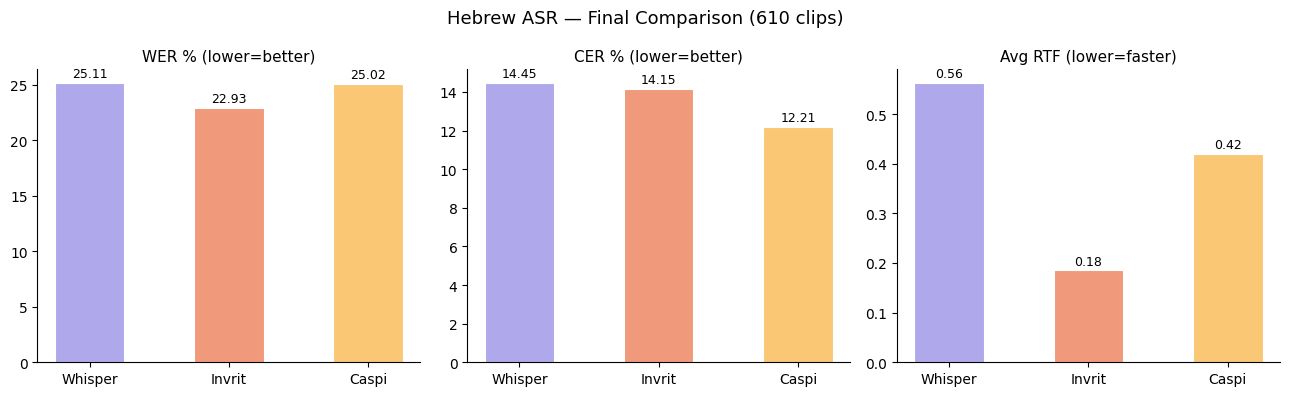

Chart saved.


In [ ]:
import re, json, unicodedata, matplotlib.pyplot as plt, os
from jiwer import wer, cer

def normalize_hebrew(text):
    if not isinstance(text, str): return ''
    text = unicodedata.normalize('NFKC', text)
    text = re.sub(r'[\u0591-\u05C7]', '', text)
    text = text.replace('ך','כ').replace('ם','מ').replace('ן','נ').replace('ף','פ').replace('ץ','צ')
    text = re.sub(r'[^0-9A-Za-z\u05D0-\u05EA\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def score(results, name):
    scored = [r for r in results if r.get('reference','').strip()]
    if not scored: return None
    refs = [normalize_hebrew(r['reference']) for r in scored]
    hyps = [normalize_hebrew(r['text'])      for r in scored]
    return {'model': name, 'clips': len(scored),
            'wer': round(wer(refs, hyps)*100, 2),
            'cer': round(cer(refs, hyps)*100, 2),
            'rtf': round(sum(r['rtf'] for r in results)/len(results), 3)}

all_scores = []
for name, res in [
    ('Whisper',  globals().get('whisper_results')),
    ('Invrit',   globals().get('invrit_results')),
    ('Caspi',    globals().get('caspi_results')),
]:
    if res:
        s = score(res, name)
        if s: all_scores.append(s)

print(f'\n{"="*58}')
print(f'  {"Model":<14} {"Clips":>6} {"WER %":>7} {"CER %":>7} {"Avg RTF":>9}')
print(f'{"─"*58}')
for s in all_scores:
    print(f"  {s['model']:<14} {s['clips']:>6} {s['wer']:>6.2f}%  {s['cer']:>6.2f}%  {s['rtf']:>8.3f}x")
print(f'{"="*58}')
print('\n⚠️  Qwen3-ASR dropped — Hebrew not in supported language list')

# Chart
names  = [s['model'] for s in all_scores]
colors = ['#AFA9EC','#F0997B','#FAC775']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, vals, title in zip(
    axes,
    [[s['wer'] for s in all_scores], [s['cer'] for s in all_scores], [s['rtf'] for s in all_scores]],
    ['WER % (lower=better)', 'CER % (lower=better)', 'Avg RTF (lower=faster)'],
):
    bars = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=0.8, width=0.5)
    ax.set_title(title, fontsize=11)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)
fig.suptitle('Hebrew ASR — Final Comparison (610 clips)', fontsize=13, fontweight='500')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'final_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

In [ ]:
# Get exact dataset stats
import json, os

# Duration from samples
total_dur = sum(s['duration_s'] for s in samples)
print(f'Total clips  : {len(samples)}')
print(f'Total seconds: {total_dur:.1f}')
print(f'Total minutes: {total_dur/60:.1f}')
print(f'Total hours  : {total_dur/3600:.2f}')

# For the 610-clip subset
scored_dur = sum(s['duration_s'] for s in samples[:610])
print(f'\n610-clip subset:')
print(f'  Duration: {scored_dur/60:.1f} min')

# Check one sample to confirm dataset source
print(f'\nSample keys: {list(samples[0].keys())}')
print(f'First ref: {samples[0]["reference"][:80]}')

Total clips  : 9360
Total seconds: 27085.6
Total minutes: 451.4
Total hours  : 7.52

610-clip subset:
  Duration: 30.0 min

Sample keys: ['audio', 'sampling_rate', 'reference', 'duration_s']
First ref: יואו
